In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re

import os
import glob
import pandas as pd
import numpy as np
import re
from IPython.display import display, HTML

# Define o caminho raiz onde estão as pastas dos datasets
BASE_DIR = '/home/aki/Desktop/GitHub/Python-VO/data'

# Configurações estéticas para os gráficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

## 1. Functions

In [3]:
def plot_trajectory(file_path):
    """
    Lê um arquivo de posições (ex: *_positions.csv) e plota a trajetória (X vs Z).
    """
    if not os.path.exists(file_path):
        print(f"Arquivo não encontrado: {file_path}")
        return
        
    # Lê o CSV ignorando as linhas que começam com '#'
    df = pd.read_csv(file_path, comment='#')
    
    plt.figure(figsize=(10, 8))
    
    # Plota Ground Truth (se existir)
    if 'GT_X' in df.columns and 'GT_Z' in df.columns:
        plt.plot(df['GT_X'], df['GT_Z'], label='Ground Truth (GT)', color='black', linestyle='--', linewidth=2)
        
    # Plota Visual Odometry (VO)
    if 'VO_X' in df.columns and 'VO_Z' in df.columns:
        plt.plot(df['VO_X'], df['VO_Z'], label='Visual Odometry (VO)', color='blue')
        
    # Plota Wheel Odometry (WO)
    if 'WO_X' in df.columns and 'WO_Z' in df.columns:
        plt.plot(df['WO_X'], df['WO_Z'], label='Wheel Odometry (WO)', color='orange')
        
    # Plota Bundle Adjustment (BA)
    if 'BA_X' in df.columns and 'BA_Z' in df.columns:
        plt.plot(df['BA_X'], df['BA_Z'], label='Bundle Adj. (BA)', color='green')

    plt.title(f"Trajetória - {os.path.basename(file_path)}")
    plt.xlabel("Eixo X (metros)")
    plt.ylabel("Eixo Z (metros)")
    plt.legend()
    plt.axis('equal') # Importante para a proporção ficar correta (1m em X = 1m em Z)
    plt.show()

def plot_errors(file_path):
    """
    Lê um arquivo de erros (ex: *_errors.csv) e plota o erro por frame.
    """
    if not os.path.exists(file_path):
        print(f"Arquivo não encontrado: {file_path}")
        return
        
    df = pd.read_csv(file_path, comment='#')
    
    plt.figure(figsize=(12, 5))
    
    if 'VO_Error' in df.columns:
        plt.plot(df['Frame'], df['VO_Error'], label='Erro VO', color='blue', alpha=0.7)
        
    if 'WO_Error' in df.columns:
        plt.plot(df['Frame'], df['WO_Error'], label='Erro WO', color='orange', alpha=0.7)
        
    if 'BA_Error' in df.columns:
        plt.plot(df['Frame'], df['BA_Error'], label='Erro BA', color='green', alpha=0.7)

    plt.title(f"Erro por Frame - {os.path.basename(file_path)}")
    plt.xlabel("Frame")
    plt.ylabel("Erro Absoluto")
    plt.legend()
    plt.show()

In [4]:
def compare_vo_trajectories(dataset_folder):
    """
    Plota as trajetórias de VO de todos os arquivos '_positions.csv' em um dataset.
    """
    folder_path = os.path.join(BASE_DIR, dataset_folder)
    position_files = glob.glob(os.path.join(folder_path, '*_positions.csv'))
    
    plt.figure(figsize=(12, 10))
    
    # Adicionar o Ground Truth apenas uma vez
    if position_files:
        df_gt = pd.read_csv(position_files[0], comment='#')
        if 'GT_X' in df_gt.columns:
            plt.plot(df_gt['GT_X'], df_gt['GT_Z'], label='Ground Truth', color='black', linestyle='--', linewidth=3)
    
    for file in position_files:
        df = pd.read_csv(file, comment='#')
        # Pega o nome do arquivo para usar de legenda (ex: SIFT_FLANN_positions)
        nome_metodo = os.path.basename(file).replace('_positions.csv', '')
        
        if 'VO_X' in df.columns:
            plt.plot(df['VO_X'], df['VO_Z'], label=f'VO - {nome_metodo}', alpha=0.8)

    plt.title(f"Comparação de Trajetórias (Apenas VO) - Dataset: {dataset_folder}")
    plt.xlabel("X")
    plt.ylabel("Z")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Tira a legenda de cima do gráfico
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

In [5]:


def gerar_tres_tabelas(dataset_folder):
    folder_path = os.path.join(BASE_DIR, dataset_folder)
    error_files = glob.glob(os.path.join(folder_path, '*_errors.csv'))
    
    lista_nenhum = []
    lista_nopnp = []
    lista_ba = []
    
    for file in error_files:
        nome_arquivo = os.path.basename(file)
        # Limpa o nome para pegar apenas a combinação Detector_Matcher
        base_name = nome_arquivo.replace('_errors.csv', '').replace('_nopnp', '')
        is_nopnp = 'nopnp' in nome_arquivo
        
        vo_ate, vo_rpe = None, None
        ba_ate, ba_rpe = None, None
        
        # 1. Lê o cabeçalho para extrair métricas pré-calculadas
        with open(file, 'r') as f:
            for line in f:
                if not line.startswith('#'):
                    break
                    
                if '# VO - ATE:' in line:
                    match = re.search(r'ATE:\s*([0-9.]+)\s*\|\s*RPE:\s*([0-9.]+)', line)
                    if match:
                        vo_ate, vo_rpe = float(match.group(1)), float(match.group(2))
                        
                if '# BA - ATE:' in line:
                    match = re.search(r'ATE:\s*([0-9.]+)\s*\|\s*RPE:\s*([0-9.]+)', line)
                    if match:
                        ba_ate, ba_rpe = float(match.group(1)), float(match.group(2))
        
        # 2. Se for uma trajetória com BA e o cabeçalho não tiver a métrica, calculamos do CSV
        if ba_ate is None and not is_nopnp:
            try:
                df_temp = pd.read_csv(file, comment='#')
                if 'BA_Error' in df_temp.columns and not df_temp['BA_Error'].isna().all():
                    # Calcula o RMSE (Root Mean Square Error) da coluna BA_Error como ATE
                    ba_ate = np.sqrt((df_temp['BA_Error']**2).mean())
                    ba_rpe = 0.0 # Setado como 0 pois não é possível inferir RPE só com erro absoluto
            except Exception:
                pass

        # 3. Distribui os resultados nas 3 listas correspondentes
        if is_nopnp:
            if vo_ate is not None:
                lista_nopnp.append({'Algoritmo': base_name, 'ATE': vo_ate, 'RPE': vo_rpe})
        else:
            if vo_ate is not None:
                lista_nenhum.append({'Algoritmo': base_name, 'ATE': vo_ate, 'RPE': vo_rpe})
            if ba_ate is not None:
                lista_ba.append({'Algoritmo': base_name, 'ATE': ba_ate, 'RPE': ba_rpe})
                
    # Função auxiliar para ordenar e formatar cada DataFrame
    def formatar_df(dados):
        if not dados:
            return pd.DataFrame()
        df = pd.DataFrame(dados)
        df = df.sort_values(by=['ATE', 'RPE'], ascending=[True, True]).reset_index(drop=True)
        df.index = df.index + 1
        df.index.name = 'Posição'
        return df
        
    return formatar_df(lista_nenhum), formatar_df(lista_nopnp), formatar_df(lista_ba)

# 2. Plots

In [10]:
dataset_name = 'cusco_dataset_3' # Pode trocar para 'urban27', 'cusco_dataset_1', etc.
descritor = 'ORB'
matcher = 'KNN'
model_name = descritor + '_' + matcher

In [11]:
df_nenhum, df_nopnp, df_ba = gerar_tres_tabelas(dataset_name)

# Exibição visual limpa no Jupyter Notebook
display(HTML(f"<h3>🏆 Ranking 1: Nenhum (VO Padrão com PnP) - Dataset: {dataset_name}</h3>"))
display(df_nenhum)

display(HTML("<hr>"))

display(HTML(f"<h3>🏆 Ranking 2: NoPnP (VO sem PnP) - Dataset: {dataset_name}</h3>"))
display(df_nopnp)

display(HTML("<hr>"))

display(HTML(f"<h3>🏆 Ranking 3: BA (Bundle Adjustment) - Dataset: {dataset_name}</h3>"))
display(df_ba)

,Algoritmo,ATE,RPE
Posição,,,
1,ORB_KNN,0.4847,0.0376
2,ORB_KNN_ba,0.5387,0.0273
3,XfeatDetector_FLANN,0.6119,0.0419
4,XfeatDetector_LighterGlueMatcher,0.6265,0.0379
5,SIFT_FLANN,0.6974,0.0363
6,SuperPointDetector_FLANN,0.7415,0.0551


,Algoritmo,ATE,RPE
Posição,,,
1,XfeatDetector_FLANN,0.6263,0.0419
2,XfeatDetector_LighterGlueMatcher,0.6613,0.0359
3,SIFT_FLANN,0.6636,0.0347
4,SuperPointDetector_FLANN,0.6662,0.0432
5,ORB_KNN,0.6772,0.0405


,Algoritmo,ATE,RPE
Posição,,,
1,ORB_KNN_ba,1.843646,0.0


Arquivo não encontrado: /home/aki/Desktop/GitHub/Python-VO/data/00/ORB_KNN_positions.csv


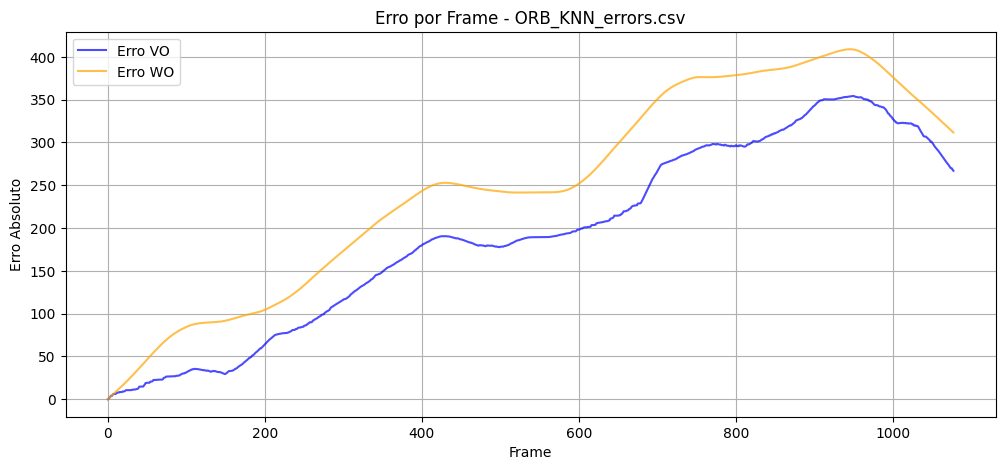

In [18]:

# Arquivos que você quer analisar
arquivo_posicoes = os.path.join(BASE_DIR, dataset_name, f'{model_name}_positions.csv')
arquivo_erros = os.path.join(BASE_DIR, dataset_name, f'{model_name}_errors.csv')

# Gerar os gráficos
plot_trajectory(arquivo_posicoes)
plot_errors(arquivo_erros)

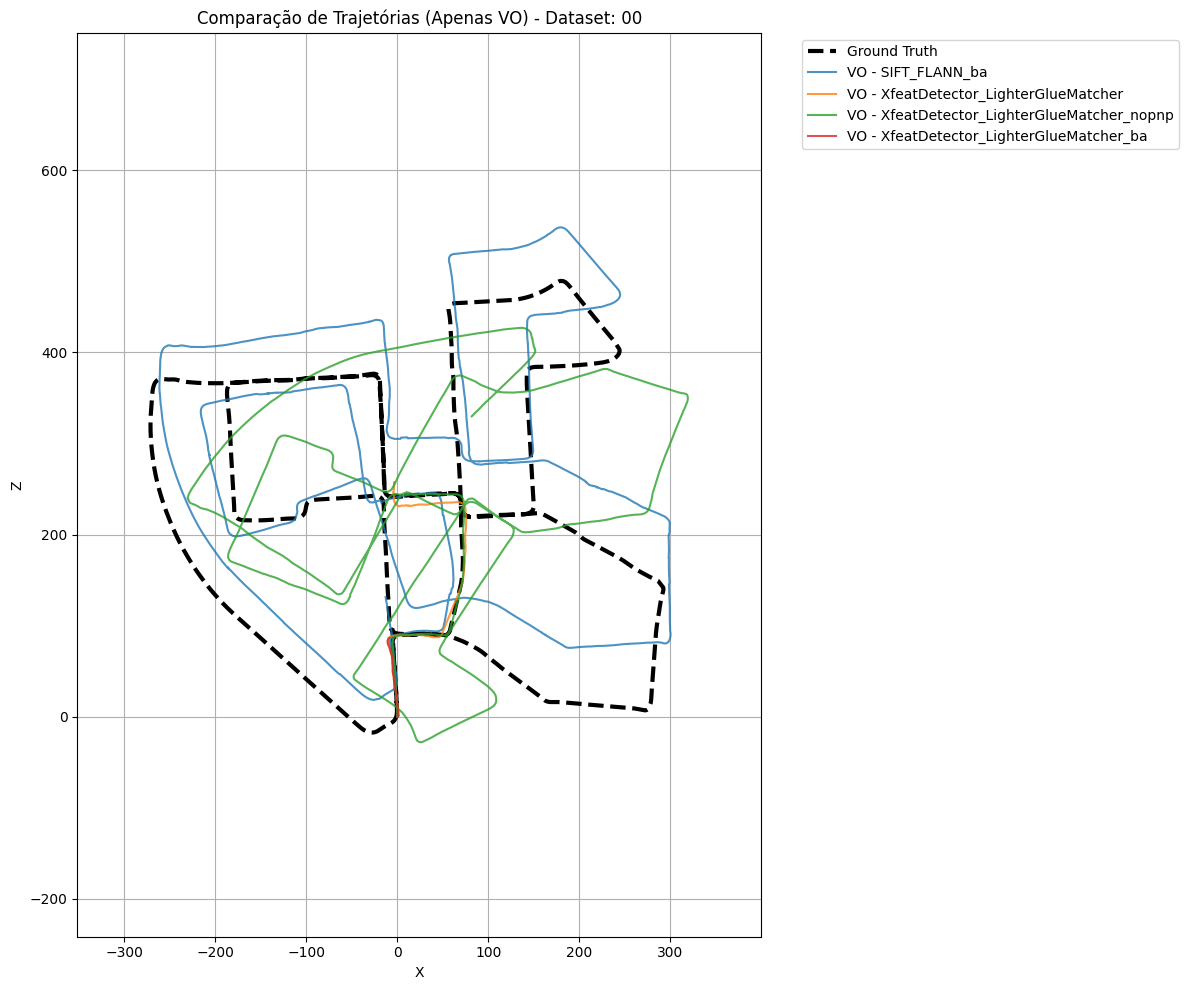

In [19]:
# Testando a comparação para o dataset '00'
compare_vo_trajectories(dataset_name)